# Pandas Data Frames

DSE5002,   HD Sheets,  July 2024, updated 6/26/2025

Pandas is a Python implementation of the R or SQL style data frame or data table

Indexing is a bit different, and there are some other "wrinkles" to indexing

There are a lot of member functions (aka *methods*) in Pandas to do a lot of basic 
data processing and graphing of data within a data frame

Pandas data frames have variables along columns,  which can be of different types

Each row is an individual event (a person, a transaction, an invoice, etc)

The dataframes in Pandas or R mimic closely the *table* seen in SQL databases.   

More resources

https://pandas.pydata.org/

In [2]:
import pandas as pd

### Free WiFi in Boston

we will load a data frame descriping public wifi access sites in Boston, it came from the site

     https://data.boston.gov/   *most cities have sites like this one*

the file is called wicked_free_wifi_boston.csv

There is a read_csv function in pandas, that will attempt to assign variable types to 
columns

You will need to insert the full file path into the variable infile below,  or make sure that the file is in the current working
directory 

below is the command from the os library to show the current working directory

we can use os.chdir() to change the current working directory

In [3]:
import os

#find out what the current working directory is using the getcwd function from the package os

os.getcwd()

'/Users/ramakrishnayalamanchili/Documents/Data Science Documents /module 2 '

In [4]:
# Make sure that the file Wicked_Free_WiFi_Locations.csv
# is in the current working directory by running os.listdir() to see directory contents

os.listdir()

['Homework_Heart_disease_data_set-1.ipynb',
 'pairprogramming_panda.pdf',
 'Pairprogramming_seaborn.pdf',
 'heart-1.csv',
 '.ipynb_checkpoints',
 'Wicked_Free_WiFi_Locations-1.csv',
 'PairProgramming_Pandas-1.ipynb',
 'PairExercise_Plotting_Seaborn-1.ipynb',
 'sales-3-1.csv']

In [5]:
# before running this cell, copy "Wicked_Free_WiFi_Locations.csv" into the current working directory
# if it is not already there


infile="Wicked_Free_WiFi_Locations-1.csv"

wifi=pd.read_csv(infile)

In [6]:
# head function,  called as a methd belonging to the dataframe (a python object) called wifi

# wifi is said to be an instance of a python dataframe

wifi.head(7)

,X,Y,neighborhood_id,neighborhood_name,device_serial,device_connectedto,device_address,device_lat,device_long,device_tags,etl_updatedtimestamp,is_current,org1,org2,inside_outside,landmark,ObjectId
0,NaN,NaN,L_601230550253963849,Mobile WiFi Kit 1,Q3AK-SUL7-7FC4,MR76-1,NaN,NaN,NaN,[],2024/08/20 04:31:34+00,1,NaN,NaN,NaN,NaN,1
1,NaN,NaN,L_601230550253963849,Mobile WiFi Kit 1,Q2ZY-RF99-YN45,MG41-1,NaN,NaN,NaN,[],2024/08/20 04:31:34+00,1,NaN,NaN,NaN,NaN,2
2,-7.912255e+06,5.206228e+06,L_601230550253964116,Nubian-Bus-Stop,Q3AE-QFTK-E55W,ROX-Nubian-AP1,"247 Washington St, Boston, MA 02121",42.301350,-71.077000,['recently-added'],2024/08/20 04:31:38+00,1,NaN,NaN,NaN,NaN,3
3,NaN,NaN,L_601230550253964116,Nubian-Bus-Stop,Q3AK-DU9C-2UXZ,ROX-Nubian_AP6,NaN,NaN,NaN,[],2024/08/20 04:31:38+00,1,NaN,NaN,NaN,NaN,4
4,NaN,NaN,L_601230550253964116,Nubian-Bus-Stop,Q3AK-FGAN-3AR9,ROX-Nubian_AP7,NaN,NaN,NaN,[],2024/08/20 04:31:38+00,1,NaN,NaN,NaN,NaN,5
5,-7.913037e+06,5.209642e+06,N_568579452955527921,Parks,Q2EK-4PWN-GALS,PARKS-FRANKLIN_CLUBHOUSE-MR84-AP1,"1 Circuit Dr., Roxbury, MA",42.324030,-71.084020,['recently-added'],2024/08/20 04:31:39+00,1,NaN,NaN,NaN,NaN,6
6,-7.913800e+06,5.210828e+06,N_579275502070532581,Roxbury,Q2CK-SSY2-PBYW,ROX-Madison Park-HS-AP1,"75 Malcolm X Blvd, Boston, MA 02120",42.331905,-71.090878,['recently-added'],2024/08/20 04:31:43+00,1,NaN,NaN,NaN,NaN,7


In [8]:
#unlike the R data frames, head doesn't show us the data types
# we need to do that manually, looking at the attribute dtypes

wifi.dtypes



X                       float64
Y                       float64
neighborhood_id          object
neighborhood_name        object
device_serial            object
device_connectedto       object
device_address           object
device_lat              float64
device_long             float64
device_tags              object
etl_updatedtimestamp     object
is_current                int64
org1                     object
org2                     object
inside_outside           object
landmark                 object
ObjectId                  int64
dtype: object

# What is the data type "object" in Pandas

An object is a string storage form

In [9]:
# Generating a Summary
# describes only numeric values

wifi.describe()

,X,Y,device_lat,device_long,is_current,ObjectId
count,2.830000e+02,2.830000e+02,283.000000,283.000000,297.0,297.000000
mean,-7.912135e+06,5.210210e+06,42.327796,-71.075917,1.0,149.000000
std,3.034883e+03,4.447129e+03,0.029537,0.027263,0.0,85.880731
min,-7.922403e+06,5.198613e+06,42.250739,-71.168161,1.0,1.000000
25%,-7.913761e+06,5.207725e+06,42.311295,-71.090520,1.0,75.000000
50%,-7.912078e+06,5.210305e+06,42.328431,-71.075407,1.0,149.000000
75%,-7.910171e+06,5.214371e+06,42.355431,-71.058271,1.0,223.000000
max,-7.904348e+06,5.218989e+06,42.386080,-71.005970,1.0,297.000000


# Subsetting and slicing in pandas

Slicing or subsetting refers to the process of extracting specific rows or columns from a dataframe that have 
the specific types of information we will need.

In [10]:
# when accessing a column,  there are several options 

n_name=wifi.neighborhood_name
w_address=wifi["device_address"]

# Pandas series
If we extract a column it is in the form of a pandas data series, which still has a lot of pandas style member
functions



In [11]:
type(n_name)

pandas.core.series.Series

In [12]:
# we can convert this to a list, using a member function

#a list is a basic data type in python, the pandas.core.series.Series is a imported *Class* from the pandas library

# Classes are custom created data storage and manipulation "objects", in the object oriented programming paradigm, more on classes
# is coming later


n_name_list=n_name.to_list()
type(n_name_list)

list

In [13]:
# dimensions of a dataframe are obtained using the attribute shape
print(wifi.shape)
print(n_name.shape)

(297, 17)
(297,)


In [14]:
#indexing several columns at a time is done by listing the column names we want

wifi[["X","Y"]].head()

,X,Y
0,NaN,NaN
1,NaN,NaN
2,-7.912255e+06,5.206228e+06
3,NaN,NaN
4,NaN,NaN


# *Question/Action*

use head to show the first 5 rows of the neighborhood id and name

In [15]:
wifi.columns
column_names_to_subset = ['neighborhood_id', 'neighborhood_name']
wifi[column_names_to_subset].head(5)


,neighborhood_id,neighborhood_name
0,L_601230550253963849,Mobile WiFi Kit 1
1,L_601230550253963849,Mobile WiFi Kit 1
2,L_601230550253964116,Nubian-Bus-Stop
3,L_601230550253964116,Nubian-Bus-Stop
4,L_601230550253964116,Nubian-Bus-Stop


In [16]:
#Basic calculations using built in *methods* or member functions in Pandas

print(wifi.device_lat.max())
print(wifi.device_lat.min())
print(wifi.device_lat.mean())

42.38608
42.2507393
42.32779576223686


## *Question/Action*

Use google to look up how to calculate the standard deviation of a Pandas variable

Use this to find the standard deviation of the longitude in this data set

In [17]:
std_value = wifi.device_long.std()
print(f'Standard Value = {std_value}')

Standard Value = 0.02726282192230917


## Slicing

Slicing is the proces of extracting specific roles that meet some criteria or condition.

It is also called filtering

This is a common task when working with dataframes or SQL tables

In [18]:
# filtering rows using conditional dependence

#let's find all devices with latitude above 42.3271405

above_wifi=wifi[wifi.device_lat>=42.3271405]
above_wifi.head()

,X,Y,neighborhood_id,neighborhood_name,device_serial,device_connectedto,device_address,device_lat,device_long,device_tags,etl_updatedtimestamp,is_current,org1,org2,inside_outside,landmark,ObjectId
6,-7.913800e+06,5.210828e+06,N_579275502070532581,Roxbury,Q2CK-SSY2-PBYW,ROX-Madison Park-HS-AP1,"75 Malcolm X Blvd, Boston, MA 02120",42.331905,-71.090878,['recently-added'],2024/08/20 04:31:43+00,1,NaN,NaN,NaN,NaN,7
7,-7.913800e+06,5.210828e+06,N_579275502070532581,Roxbury,Q2CK-SU8N-5VU8,ROX-Madison Park-HS-AP3,"75 Malcolm X Blvd, Boston, MA 02120",42.331905,-71.090878,['recently-added'],2024/08/20 04:31:43+00,1,NaN,NaN,NaN,NaN,8
15,-7.912357e+06,5.210581e+06,N_579275502070532581,Roxbury,Q2CK-HDFV-VYBC,ROX-ORCHARD-AP2,"906 Albany St., Roxbury, MA",42.330267,-71.077909,"['BPS', 'Orchard-Garden-School', 'Outside', 'r...",2024/08/20 04:31:43+00,1,BPS,NaN,Outside,Orchard Garden School,16
18,-7.912846e+06,5.210317e+06,N_579275502070532581,Roxbury,Q2CK-SF4S-8JL2,ROX-BFDE14-AP3,On pole across from BFD Engine 14,42.328514,-71.082303,"['BFD', 'Engine-14', 'Outside']",2024/08/20 04:31:43+00,1,BFD,NaN,Outside,Engine 14,19
20,-7.912858e+06,5.210361e+06,N_579275502070532581,Roxbury,Q2CK-MR56-4QY6,ROX-BFDE14-AP2,"174 Dudley St., Roxbury, MA - Front Roof Facin...",42.328809,-71.082409,"['BFD', 'Engine-14', 'Outside']",2024/08/20 04:31:43+00,1,BFD,NaN,Outside,Engine 14,21


In [19]:
#slicing by values in a set, notice that pandas has a isin() member function for this

wifi[wifi.neighborhood_name.isin(["Parks","Charlestown"])]

,X,Y,neighborhood_id,neighborhood_name,device_serial,device_connectedto,device_address,device_lat,device_long,device_tags,etl_updatedtimestamp,is_current,org1,org2,inside_outside,landmark,ObjectId
5,-7.913037e+06,5.209642e+06,N_568579452955527921,Parks,Q2EK-4PWN-GALS,PARKS-FRANKLIN_CLUBHOUSE-MR84-AP1,"1 Circuit Dr., Roxbury, MA",42.324030,-71.084020,['recently-added'],2024/08/20 04:31:39+00,1,NaN,NaN,NaN,NaN,6
28,-7.910979e+06,5.214437e+06,N_568579452955527921,Parks,Q3AK-CVAE-CUZU,PARKS-COMMON-AP6,Boston Common,42.355872,-71.065536,[],2024/08/20 04:31:39+00,1,NaN,NaN,NaN,NaN,29
44,-7.916707e+06,5.202882e+06,N_568579452955527921,Parks,Q2AK-U4TT-J95L,PARKS-MTHOPE-AP1,"Mt Hope Cemetery, Hyde Park, MA - Cummings Hwy...",42.279119,-71.116991,"['Mount-Hope-Cemetery', 'Outside']",2024/08/20 04:31:39+00,1,NaN,NaN,Outside,Mount Hope Cemetery,45
188,-7.910482e+06,5.218089e+06,N_568579452955538062,Charlestown,Q2CK-V3LS-5V65,CHL-BCYF-AP2,"240 Medford St, Charlestown, MA 02129",42.380109,-71.061070,"['BCYF', 'BCYF-Grant', 'Charlestown-Athletic-B...",2024/08/20 04:31:40+00,1,BCYF,NaN,Outside,Charlestown Athletic Building,189
202,-7.910805e+06,5.214387e+06,N_568579452955527921,Parks,Q3AK-DGSZ-GM7H,PARKS-COMMON-AP7,Boston Common,42.355539,-71.063969,[],2024/08/20 04:31:39+00,1,NaN,NaN,NaN,NaN,203
203,-7.911261e+06,5.214274e+06,N_568579452955527921,Parks,Q3AK-EK6U-T4FW,PARKS-COMMON-AP2,Boston Common,42.354786,-71.068068,[],2024/08/20 04:31:39+00,1,NaN,NaN,NaN,NaN,204
205,-7.910482e+06,5.218089e+06,N_568579452955538062,Charlestown,Q2CK-CWUY-RBGW,CHL-HIGHSCHOOL-AP1,"240 Medford St., Charlestown, MA",42.380109,-71.061070,"['BPS', 'Charlestown-High-School', 'Outside']",2024/08/20 04:31:40+00,1,BPS,NaN,Outside,Charlestown High School,206
214,-7.911012e+06,5.214442e+06,N_568579452955527921,Parks,Q3AK-DRLB-LEZF,PARKS-COMMON-AP5,Boston Common,42.355900,-71.065831,[],2024/08/20 04:31:39+00,1,NaN,NaN,NaN,NaN,215
223,-7.910482e+06,5.218089e+06,N_568579452955538062,Charlestown,Q2CK-SNTB-WJWA,CHL-HIGHSCHOOL-AP2,"240 Medford St, Charlestown, MA 02129",42.380109,-71.061070,"['BCYF-Grant', 'BPS', 'Charlestown-High-School...",2024/08/20 04:31:40+00,1,BPS,NaN,Outside,Charlestown High School,224
226,-7.911133e+06,5.214283e+06,N_568579452955527921,Parks,Q3AK-CR6K-YPBC,PARKS-COMMON-AP4,Boston Common,42.354849,-71.066920,[],2024/08/20 04:31:39+00,1,NaN,NaN,NaN,NaN,227


In [24]:
# notna returns true or false depending on whether there are Nan values in the locations
# the list of True/False values produced by notna can be used to slice, so selecting all the rows
# whose X coordinates are not NA

wifi[wifi.X.notna()].head()

,X,Y,neighborhood_id,neighborhood_name,device_serial,device_connectedto,device_address,device_lat,device_long,device_tags,etl_updatedtimestamp,is_current,org1,org2,inside_outside,landmark,ObjectId
2,-7.912255e+06,5.206228e+06,L_601230550253964116,Nubian-Bus-Stop,Q3AE-QFTK-E55W,ROX-Nubian-AP1,"247 Washington St, Boston, MA 02121",42.301350,-71.077000,['recently-added'],2024/08/20 04:31:38+00,1,NaN,NaN,NaN,NaN,3
5,-7.913037e+06,5.209642e+06,N_568579452955527921,Parks,Q2EK-4PWN-GALS,PARKS-FRANKLIN_CLUBHOUSE-MR84-AP1,"1 Circuit Dr., Roxbury, MA",42.324030,-71.084020,['recently-added'],2024/08/20 04:31:39+00,1,NaN,NaN,NaN,NaN,6
6,-7.913800e+06,5.210828e+06,N_579275502070532581,Roxbury,Q2CK-SSY2-PBYW,ROX-Madison Park-HS-AP1,"75 Malcolm X Blvd, Boston, MA 02120",42.331905,-71.090878,['recently-added'],2024/08/20 04:31:43+00,1,NaN,NaN,NaN,NaN,7
7,-7.913800e+06,5.210828e+06,N_579275502070532581,Roxbury,Q2CK-SU8N-5VU8,ROX-Madison Park-HS-AP3,"75 Malcolm X Blvd, Boston, MA 02120",42.331905,-71.090878,['recently-added'],2024/08/20 04:31:43+00,1,NaN,NaN,NaN,NaN,8
8,-7.913466e+06,5.208391e+06,N_579275502070532581,Roxbury,Q2CK-H5VS-5UKS,ROX-TROTTER-AP1,"135 Humboldt Ave., Roxbury, MA",42.315723,-71.087872,"['BPS', 'Outside', 'Trotter-School']",2024/08/20 04:31:43+00,1,BPS,NaN,Outside,Trotter School,9


In [20]:
# there is also a str.contains function, which searches for a regex string within the column values
# we will talk about regex in more detail later

# notice the use of .str.contains(),   a string function within pandas

# see https://pandas.pydata.org/docs/user_guide/text.html for a bunch of examples of pandas string functions

wifi[wifi.neighborhood_name.str.contains("town")]

,X,Y,neighborhood_id,neighborhood_name,device_serial,device_connectedto,device_address,device_lat,device_long,device_tags,etl_updatedtimestamp,is_current,org1,org2,inside_outside,landmark,ObjectId
53,-7.910171e+06,5.215103e+06,N_601230550253961310,Downtown Boston - City Hall - Quincy Market,Q3AE-4FLA-SJCJ,DT-Beer garden 2- higher level of beer garden,One City Hall Sq Boston MA 02201,42.360291,-71.058271,[],2024/08/20 04:31:44+00,1,NaN,NaN,NaN,NaN,54
54,-7.910171e+06,5.215103e+06,N_601230550253961310,Downtown Boston - City Hall - Quincy Market,Q3AE-HJRQ-D68Q,DT-CITYHALL-GUARDSHACK,One City Hall Sq Boston MA 02201,42.360291,-71.058271,[],2024/08/20 04:31:44+00,1,NaN,NaN,NaN,NaN,55
55,-7.909698e+06,5.215107e+06,N_601230550253961310,Downtown Boston - City Hall - Quincy Market,Q3AE-ARNB-HFAK,DT-QUINCYMARKET-AP2,Faneuil Hall Marketplace\nBoston MA 02201,42.360320,-71.054029,[],2024/08/20 04:31:44+00,1,NaN,NaN,NaN,NaN,56
56,-7.909702e+06,5.215082e+06,N_601230550253961310,Downtown Boston - City Hall - Quincy Market,Q3AE-PMFQ-JUX3,DT-QUINCYMARKET-AP4,Faneuil Hall Marketplace\nBoston MA 02201,42.360153,-71.054061,[],2024/08/20 04:31:44+00,1,NaN,NaN,NaN,NaN,57
57,-7.910171e+06,5.215103e+06,N_601230550253961310,Downtown Boston - City Hall - Quincy Market,Q3AE-3S8D-CZPE,DT-CITYHALL-4th-Floor-Patio-Daycare,One City Hall Sq Boston MA 02201,42.360291,-71.058271,[],2024/08/20 04:31:44+00,1,NaN,NaN,NaN,NaN,58
58,-7.909943e+06,5.215065e+06,N_601230550253961310,Downtown Boston - City Hall - Quincy Market,Q3AK-C98F-JUR2,Faneuil-Hall-Marketplace-window1,"1 Faneuil Hall Sq, Boston, MA 02109",42.360039,-71.056228,[],2024/08/20 04:31:44+00,1,NaN,NaN,NaN,NaN,59
59,-7.910171e+06,5.215103e+06,N_601230550253961310,Downtown Boston - City Hall - Quincy Market,Q3AE-TBT5-D72C,DT-Beer garden 1- lower part of beer garden,One City Hall Sq Boston MA 02201,42.360291,-71.058271,[],2024/08/20 04:31:44+00,1,NaN,NaN,NaN,NaN,60
61,-7.909943e+06,5.215065e+06,N_601230550253961310,Downtown Boston - City Hall - Quincy Market,Q3AK-D5DU-9HST,Faneuil-Hall-Marketplace-window,"1 Faneuil Hall Sq, Boston, MA 02109",42.360039,-71.056228,['recently-added'],2024/08/20 04:31:44+00,1,NaN,NaN,NaN,NaN,62
62,-7.910171e+06,5.215103e+06,N_601230550253961310,Downtown Boston - City Hall - Quincy Market,Q3AE-ZUF3-Y73P,DT-CITYHALL-4th-Floor-Patio-AP1,One City Hall Sq Boston MA 02201,42.360291,-71.058271,[],2024/08/20 04:31:44+00,1,NaN,NaN,NaN,NaN,63
69,-7.909890e+06,5.215063e+06,N_601230550253961310,Downtown Boston - City Hall - Quincy Market,Q3AE-F6RV-VVHP,DT-QUINCYMARKET-AP3,Faneuil Hall Marketplace\nBoston MA 02201,42.360022,-71.055751,[],2024/08/20 04:31:44+00,1,NaN,NaN,NaN,NaN,70


In [21]:
# Row and column specification
# use paired conctions on [row,column]
# we now have to use the method .loc[] to do this

wifi.loc[wifi.X.notna(),"X"].head()

2   -7.912255e+06
5   -7.913037e+06
6   -7.913800e+06
7   -7.913800e+06
8   -7.913466e+06
Name: X, dtype: float64

In [22]:
# you have to have a boolean return type in the row indexing function or a set of integers
# we can send a list of column names to get several of them

wifi.loc[wifi.neighborhood_name.str.contains("Charlestown"),['device_lat','device_long']].head()


,device_lat,device_long
188,42.380109,-71.06107
205,42.380109,-71.06107
223,42.380109,-71.06107


In [23]:
# Indexing using integer values is done using the iloc[] function

# so remember- used .loc for boolean and named columns,   .iloc for Integer locations

wifi.iloc[0:8,0:6]

,X,Y,neighborhood_id,neighborhood_name,device_serial,device_connectedto
0,NaN,NaN,L_601230550253963849,Mobile WiFi Kit 1,Q3AK-SUL7-7FC4,MR76-1
1,NaN,NaN,L_601230550253963849,Mobile WiFi Kit 1,Q2ZY-RF99-YN45,MG41-1
2,-7.912255e+06,5.206228e+06,L_601230550253964116,Nubian-Bus-Stop,Q3AE-QFTK-E55W,ROX-Nubian-AP1
3,NaN,NaN,L_601230550253964116,Nubian-Bus-Stop,Q3AK-DU9C-2UXZ,ROX-Nubian_AP6
4,NaN,NaN,L_601230550253964116,Nubian-Bus-Stop,Q3AK-FGAN-3AR9,ROX-Nubian_AP7
5,-7.913037e+06,5.209642e+06,N_568579452955527921,Parks,Q2EK-4PWN-GALS,PARKS-FRANKLIN_CLUBHOUSE-MR84-AP1
6,-7.913800e+06,5.210828e+06,N_579275502070532581,Roxbury,Q2CK-SSY2-PBYW,ROX-Madison Park-HS-AP1
7,-7.913800e+06,5.210828e+06,N_579275502070532581,Roxbury,Q2CK-SU8N-5VU8,ROX-Madison Park-HS-AP3


# Plotting with Pandas functions

Pandas has basic plotting built in

I typically use Matplotlib, but Pandas has the basics, scatterplots (aka biplots),  box and whisker plots, and histograms

<Axes: xlabel='device_long', ylabel='device_lat'>

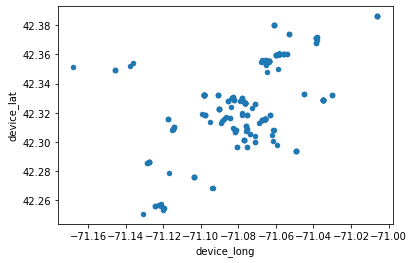

In [24]:
#Pandas built in plots

wifi.plot.scatter(x="device_long",y="device_lat")

<Axes: >

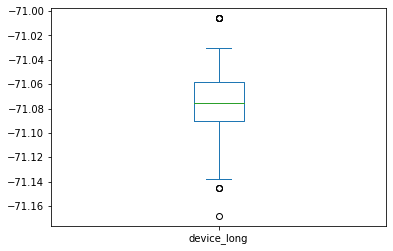

In [25]:
#here is a boxplot aka a box and whisker plot

# the green bar in the middle of the box is the median value,
# the ends of the box are the 25% and 75% quantiles (so 50% of the data is in the box
# the ends of the whiskers are the farthest specimen that is within 1.5 times the height of 
# the box away from the box, this is roughly the typical expected range of values 
# points beyond the whiskers are nominally outliers, although this identification 
# that they are outliers is based on questionable assumptions

wifi[["device_long"]].plot.box()

<Axes: ylabel='Frequency'>

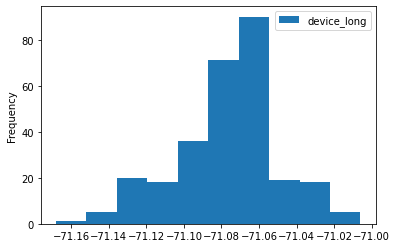

In [26]:
#histogram

wifi[["device_long"]].plot.hist()

In [32]:
#creating new columns

#just name the column and assign a value

# this is a nonsensical value, but it shows the idea

wifi["x over y"]= wifi.X/wifi.Y

wifi.head()

,X,Y,neighborhood_id,neighborhood_name,device_serial,device_connectedto,device_address,device_lat,device_long,device_tags,etl_updatedtimestamp,is_current,org1,org2,inside_outside,landmark,ObjectId,x over y
0,NaN,NaN,L_601230550253963849,Mobile WiFi Kit 1,Q3AK-SUL7-7FC4,MR76-1,NaN,NaN,NaN,[],2024/08/20 04:31:34+00,1,NaN,NaN,NaN,NaN,1,NaN
1,NaN,NaN,L_601230550253963849,Mobile WiFi Kit 1,Q2ZY-RF99-YN45,MG41-1,NaN,NaN,NaN,[],2024/08/20 04:31:34+00,1,NaN,NaN,NaN,NaN,2,NaN
2,-7.912255e+06,5.206228e+06,L_601230550253964116,Nubian-Bus-Stop,Q3AE-QFTK-E55W,ROX-Nubian-AP1,"247 Washington St, Boston, MA 02121",42.30135,-71.077,['recently-added'],2024/08/20 04:31:38+00,1,NaN,NaN,NaN,NaN,3,-1.519767
3,NaN,NaN,L_601230550253964116,Nubian-Bus-Stop,Q3AK-DU9C-2UXZ,ROX-Nubian_AP6,NaN,NaN,NaN,[],2024/08/20 04:31:38+00,1,NaN,NaN,NaN,NaN,4,NaN
4,NaN,NaN,L_601230550253964116,Nubian-Bus-Stop,Q3AK-FGAN-3AR9,ROX-Nubian_AP7,NaN,NaN,NaN,[],2024/08/20 04:31:38+00,1,NaN,NaN,NaN,NaN,5,NaN


# Aggregation or grouping for tables and statistics

Pandas as a nice groupby function,  reminiscent of the dplyr methods

In [33]:
# we specify the columns we want to work with in the dataframe, then specify which are the grouping variables

# at the end, we add a Pandas summary function

# Note, if we had more grouping variables the input to groupby could be a list


wifi[["device_long","device_lat","neighborhood_name"]].groupby("neighborhood_name").mean()

,device_long,device_lat
neighborhood_name,,
2 Center Plaza,-71.060201,42.359796
Alston Brighton,-71.146410,42.350730
BCYF Indoor,-71.084504,42.320980
BCYF Tremont,-71.098229,42.332227
BCYF-Curley,-71.035150,42.329115
Bolling,-71.083664,42.330141
Charlestown,-71.061070,42.380109
City Hall Truck,NaN,NaN
Dorchester,-71.067166,42.306111


## Multiple grouping variables


In [34]:
# we can use groupby to get counts per grouping variable as well
# I tried using is_current as a grouping variable, but they are all 1, indicating current

wifi[["device_long","device_lat","neighborhood_name","is_current"]].groupby(["neighborhood_name","is_current"]).count()

,,device_long,device_lat
neighborhood_name,is_current,,
2 Center Plaza,1,6,6
Alston Brighton,1,6,6
BCYF Indoor,1,27,27
BCYF Tremont,1,9,9
BCYF-Curley,1,12,12
Bolling,1,6,6
Charlestown,1,3,3
City Hall Truck,1,0,0
Dorchester,1,24,24


# Categorical data

We can set data to be of type Categorical,  which is akin to a factor

It is also possible to use integer group codes or dummy coding to represent categories or factors,  this is done using utility tools in 
libraries such as scikit-learn or keras that focus on modeling



In [35]:
wifi['neighborhood_name']=pd.Categorical(wifi.neighborhood_name)

wifi.head()

,X,Y,neighborhood_id,neighborhood_name,device_serial,device_connectedto,device_address,device_lat,device_long,device_tags,etl_updatedtimestamp,is_current,org1,org2,inside_outside,landmark,ObjectId,x over y
0,NaN,NaN,L_601230550253963849,Mobile WiFi Kit 1,Q3AK-SUL7-7FC4,MR76-1,NaN,NaN,NaN,[],2024/08/20 04:31:34+00,1,NaN,NaN,NaN,NaN,1,NaN
1,NaN,NaN,L_601230550253963849,Mobile WiFi Kit 1,Q2ZY-RF99-YN45,MG41-1,NaN,NaN,NaN,[],2024/08/20 04:31:34+00,1,NaN,NaN,NaN,NaN,2,NaN
2,-7.912255e+06,5.206228e+06,L_601230550253964116,Nubian-Bus-Stop,Q3AE-QFTK-E55W,ROX-Nubian-AP1,"247 Washington St, Boston, MA 02121",42.30135,-71.077,['recently-added'],2024/08/20 04:31:38+00,1,NaN,NaN,NaN,NaN,3,-1.519767
3,NaN,NaN,L_601230550253964116,Nubian-Bus-Stop,Q3AK-DU9C-2UXZ,ROX-Nubian_AP6,NaN,NaN,NaN,[],2024/08/20 04:31:38+00,1,NaN,NaN,NaN,NaN,4,NaN
4,NaN,NaN,L_601230550253964116,Nubian-Bus-Stop,Q3AK-FGAN-3AR9,ROX-Nubian_AP7,NaN,NaN,NaN,[],2024/08/20 04:31:38+00,1,NaN,NaN,NaN,NaN,5,NaN


In [36]:
# did this work

wifi.dtypes

X                        float64
Y                        float64
neighborhood_id           object
neighborhood_name       category
device_serial             object
device_connectedto        object
device_address            object
device_lat               float64
device_long              float64
device_tags               object
etl_updatedtimestamp      object
is_current                 int64
org1                      object
org2                      object
inside_outside            object
landmark                  object
ObjectId                   int64
x over y                 float64
dtype: object

# *Question/Action*

What other variables should be Categorical variables (there aren't many)

Convert this variable to a category                                



In [38]:
#inside_outside; landmark
wifi['inside_outside'] = pd.Categorical(wifi.inside_outside)
wifi['landmark'] = pd.Categorical(wifi.landmark)
wifi.head()

,X,Y,neighborhood_id,neighborhood_name,device_serial,device_connectedto,device_address,device_lat,device_long,device_tags,etl_updatedtimestamp,is_current,org1,org2,inside_outside,landmark,ObjectId,x over y
0,NaN,NaN,L_601230550253963849,Mobile WiFi Kit 1,Q3AK-SUL7-7FC4,MR76-1,NaN,NaN,NaN,[],2024/08/20 04:31:34+00,1,NaN,NaN,NaN,NaN,1,NaN
1,NaN,NaN,L_601230550253963849,Mobile WiFi Kit 1,Q2ZY-RF99-YN45,MG41-1,NaN,NaN,NaN,[],2024/08/20 04:31:34+00,1,NaN,NaN,NaN,NaN,2,NaN
2,-7.912255e+06,5.206228e+06,L_601230550253964116,Nubian-Bus-Stop,Q3AE-QFTK-E55W,ROX-Nubian-AP1,"247 Washington St, Boston, MA 02121",42.30135,-71.077,['recently-added'],2024/08/20 04:31:38+00,1,NaN,NaN,NaN,NaN,3,-1.519767
3,NaN,NaN,L_601230550253964116,Nubian-Bus-Stop,Q3AK-DU9C-2UXZ,ROX-Nubian_AP6,NaN,NaN,NaN,[],2024/08/20 04:31:38+00,1,NaN,NaN,NaN,NaN,4,NaN
4,NaN,NaN,L_601230550253964116,Nubian-Bus-Stop,Q3AK-FGAN-3AR9,ROX-Nubian_AP7,NaN,NaN,NaN,[],2024/08/20 04:31:38+00,1,NaN,NaN,NaN,NaN,5,NaN


# Dummy Coding

It looks like Pandas can generate dummy codes for us

Pandas does not have a 'factor' variable, so in models like multiple regression,   logisitic regression or neural networks, we use dummy coding to code categorical variables.  You will see more on this later.

What does this look like?

What does a True in this table seem to mean?

This is also called "one-hot" encoding, since there is only one "True" per row of the table

In [40]:
pd.get_dummies(wifi.neighborhood_name)

,2 Center Plaza,Alston Brighton,BCYF Indoor,BCYF Tremont,BCYF-Curley,Bolling,Charlestown,City Hall Truck,Dorchester,Downtown Boston - City Hall - Quincy Market,...,Navy Yard,Nubian-Bus-Stop,OPAT,Parks,Roslindale,Roxbury,South Boston,Strand Theatre - External,Strand Theatre - Internal,YEE Tremont
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
293,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
294,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
295,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# *Question/Action*

Create a dummy coding for the variable that you turned into a Categorical variable in the Question above

In [39]:
pd.get_dummies(wifi.landmark)

,Bolling,Bolling CoB Employee,Boston Common,Boston Latin Academy,Brighton High School,Centre South Main Street Curtis Hall,Centre South Main Street Lightpole,Charlestown,Charlestown Athletic Building,Charlestown High School,...,Roxbury Shelburne,Shelbourne Comm Center,South Boston High School,Tobin Comm Center,Trotter School,UXI employee,Uphams Corner Branch,Vine St Comm Center,Winthrop School,employee
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
293,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
294,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
295,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# date-time values

It looks like we have one date-time variable in the dataset right now

etl_updatedtimestamp  

it looks like a fairly standard format

In [41]:
wifi.etl_updatedtimestamp.head(5)

0    2024/08/20 04:31:34+00
1    2024/08/20 04:31:34+00
2    2024/08/20 04:31:38+00
3    2024/08/20 04:31:38+00
4    2024/08/20 04:31:38+00
Name: etl_updatedtimestamp, dtype: object

In [42]:
wifi.etl_updatedtimestamp=pd.to_datetime(wifi.etl_updatedtimestamp)
wifi.etl_updatedtimestamp.head()

0   2024-08-20 04:31:34+00:00
1   2024-08-20 04:31:34+00:00
2   2024-08-20 04:31:38+00:00
3   2024-08-20 04:31:38+00:00
4   2024-08-20 04:31:38+00:00
Name: etl_updatedtimestamp, dtype: datetime64[ns, UTC]

In [43]:
# We can now get days, months, years

wifi.etl_updatedtimestamp.dt.day.head()

0    20
1    20
2    20
3    20
4    20
Name: etl_updatedtimestamp, dtype: int64

In [44]:
wifi.etl_updatedtimestamp.dt.month.head()

0    8
1    8
2    8
3    8
4    8
Name: etl_updatedtimestamp, dtype: int64

In [ ]:
wifi.etl_updatedtimestamp.dt.year.head()

# Converting to Long form
uses the melt function

https://pandas.pydata.org/docs/reference/api/pandas.melt.html

Form more ideas on wide to long, look up

Pandas pivot
pandas pivot_table
pandas unstack
pandas wide_to_long

In [28]:
df = pd.DataFrame({'A': {0: 'a', 1: 'b', 2: 'c'},
                   'B': {0: 1, 1: 3, 2: 5},
                   'C': {0: 2, 1: 4, 2: 6}})

df

,A,B,C
0,a,1,2
1,b,3,4
2,c,5,6


In [29]:
pd.melt(df, )

,variable,value
0,A,a
1,A,b
2,A,c
3,B,1
4,B,3
5,B,5
6,C,2
7,C,4
8,C,6


In [30]:
# note we specify a list of i variables and a list of value variables,  much like in tidyR


pd.melt(df, id_vars=['A'], value_vars=['B','C'])

,A,variable,value
0,a,B,1
1,b,B,3
2,c,B,5
3,a,C,2
4,b,C,4
5,c,C,6


In [31]:
# alternative form, two id variables
# this is a "composite key" form

pd.melt(df, id_vars=['A','C'], value_vars=['B'])

,A,C,variable,value
0,a,2,B,1
1,b,4,B,3
2,c,6,B,5


In [32]:
# create df2 for question/action

df2 = pd.DataFrame({'A': {0: 'a', 1: 'b', 2: 'c',3:'d'},
                   'B': {0: 1, 1: 3, 2: 5,3: 6},
                   'C': {0: 2, 1: 4, 2: 6,3: 8},
                   'D': {0:"Biscuit",1:"Chips",2:"Banana",3:"hard case"}})
df2

,A,B,C,D
0,a,1,2,Biscuit
1,b,3,4,Chips
2,c,5,6,Banana
3,d,6,8,hard case


In [34]:
df2_unstacked = df2.set_index(['A']).unstack() 
print(df2_unstacked)

   A
B  a            1
   b            3
   c            5
   d            6
C  a            2
   b            4
   c            6
   d            8
D  a      Biscuit
   b        Chips
   c       Banana
   d    hard case
dtype: object


# *Question/Action*

Melt df2 to wide form,  using D and A as the index variables,   assign the other two columns as values

In [50]:
pd.melt(df2, id_vars=['D','A'], value_vars=['B', 'C'])

,D,A,variable,value
0,Biscuit,a,B,1
1,Chips,b,B,3
2,Banana,c,B,5
3,hard case,d,B,6
4,Biscuit,a,C,2
5,Chips,b,C,4
6,Banana,c,C,6
7,hard case,d,C,8


# Joins

A join connects two dataframes (or SQL data tables) together based on matching values of keys (identifiers) in the two data frames or tables.
You may have seen this in R, and we will see it again in SQL.

Joins are done on two dataframes (or tables) at a time, the first is called the "left" table and the second is called the "right" table and several different forms of joins exist.

Joins are done on Pandas data frames are done using the merge function

You can specify the type of join desired,  inner, outer, left, right etc

https://pandas.pydata.org/docs/reference/api/pandas.merge.html

Joins are also common when working with SQL, so we will see the join concept again later when we discuss SQL

In [51]:
df1 = pd.DataFrame({'lkey': ['foo', 'bar', 'baz', 'foo',"bix"],'value': [1, 2, 3, 5,11]})
df2 = pd.DataFrame({'rkey': ['foo', 'bar', 'baz', 'foo'],'value': [5, 6, 7, 8]})


In [52]:
df1

,lkey,value
0,foo,1
1,bar,2
2,baz,3
3,foo,5
4,bix,11


In [53]:
df2

,rkey,value
0,foo,5
1,bar,6
2,baz,7
3,foo,8


In [54]:
# this is an inner join of the left frame df1 and the right frame df2

# notice that "bix" was dropped

df1.merge(df2, left_on='lkey', right_on='rkey')

,lkey,value_x,rkey,value_y
0,foo,1,foo,5
1,foo,1,foo,8
2,foo,5,foo,5
3,foo,5,foo,8
4,bar,2,bar,6
5,baz,3,baz,7


In [55]:
# here is a left join

# what happens to "bix"?

df1.merge(df2, how="left",left_on='lkey', right_on='rkey')

,lkey,value_x,rkey,value_y
0,foo,1,foo,5.0
1,foo,1,foo,8.0
2,bar,2,bar,6.0
3,baz,3,baz,7.0
4,foo,5,foo,5.0
5,foo,5,foo,8.0
6,bix,11,NaN,NaN


In [ ]:
Bix remained because bix is in the left one and it was a left join not one where you combine the variables and both have to be there like inner join. 
Left join showcases all of the variables in the left category. 